<a href="https://colab.research.google.com/github/vrundan7/carla-ml-safety/blob/main/fgsm_robustness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/2026 (1)/2026"

import os
import csv
import random
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms, models
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score

import matplotlib.pyplot as plt

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_DIR = f"{BASE_PATH}/model_outputs"
LABELS = ['has_traffic_light', 'has_pedestrian', 'has_vehicle']
EPSILONS = [0.0, 0.01, 0.05, 0.1]  # 0.0 = clean baseline
N_SAMPLES = 100  # per split

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

TEST_SPLITS = {
    "test":         {"csv": f"{BASE_PATH}/test/test/labels.csv",
                     "img": f"{BASE_PATH}/test/test/rgb-front"},
    "test-fog":     {"csv": f"{BASE_PATH}/test-fog/test-fog/labels.csv",
                     "img": f"{BASE_PATH}/test-fog/test-fog/rgb-front"},
    "test-night":   {"csv": f"{BASE_PATH}/test-night/test-night/labels.csv",
                     "img": f"{BASE_PATH}/test-night/test-night/rgb-front"},
    "test-town-01": {"csv": f"{BASE_PATH}/test-town-01/test-town-01/labels.csv",
                     "img": f"{BASE_PATH}/test-town-01/test-town-01/rgb-front"},
}

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

print(f"Device: {DEVICE}")
print(f"Evaluating {N_SAMPLES} samples per split.\n")



Mounted at /content/drive
Device: cuda
Evaluating 100 samples per split.



FGSM + Helpers

In [ ]:

def load_model(label_col):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(512, 1)
    model.load_state_dict(torch.load(
        os.path.join(MODEL_DIR, f"best_{label_col}.pth"), map_location=DEVICE))
    model.to(DEVICE).eval()
    return model

def load_samples(csv_path, img_dir, max_n=None):
    samples = []
    with open(csv_path, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            frame = row['frame']
            p = os.path.join(img_dir, f"{frame}.jpg")
            if os.path.exists(p):
                samples.append({
                    'frame': frame, 'img_path': p,
                    'has_traffic_light': row['has_traffic_light'] == 'True',
                    'has_pedestrian': row['has_pedestrian'] == 'True',
                    'has_vehicle': row['has_vehicle'] == 'True',
                })
    if max_n and len(samples) > max_n:
        samples = random.sample(samples, max_n)
    return samples

def fgsm_attack(model, image_tensor, label, epsilon, criterion):
    """FGSM: x_adv = x + ε · sign(∇_x L(y, f(x)))"""
    if epsilon == 0.0:
        # Clean — no attack
        with torch.no_grad():
            out = model(image_tensor.to(DEVICE))
            prob = torch.sigmoid(out).item()
        return 1.0 if prob > 0.5 else 0.0, prob

    image_tensor = image_tensor.clone().detach().to(DEVICE)
    image_tensor.requires_grad = True
    label = label.to(DEVICE)

    output = model(image_tensor)
    loss = criterion(output, label)
    model.zero_grad()
    loss.backward()

    grad_sign = image_tensor.grad.data.sign()
    perturbed = image_tensor + epsilon * grad_sign

    # Clamp to valid normalized range
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(DEVICE)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(DEVICE)
    perturbed = torch.max(torch.min(perturbed, (1 - mean) / std), (0 - mean) / std)

    with torch.no_grad():
        adv_prob = torch.sigmoid(model(perturbed)).item()

    return 1.0 if adv_prob > 0.5 else 0.0, adv_prob

criterion = nn.BCEWithLogitsLoss()
models_dict = {l: load_model(l) for l in LABELS}
print("✅ Models loaded.")



✅ Models loaded.


Evaluate Recall Under Attack — All Models × All Splits × All ε

In [ ]:

results = []  # list of dicts

for split_name, paths in TEST_SPLITS.items():
    if not os.path.exists(paths["csv"]):
        print(f"⚠️  {split_name} not found")
        continue

    samples = load_samples(paths["csv"], paths["img"], max_n=N_SAMPLES)
    print(f"\n{'='*70}")
    print(f"  {split_name}  ({len(samples)} samples)")
    print(f"{'='*70}")

    for label_col in LABELS:
        model = models_dict[label_col]

        for eps in EPSILONS:
            y_true, y_pred = [], []

            for s in samples:
                img = Image.open(s['img_path']).convert('RGB')
                img_t = test_transform(img).unsqueeze(0)
                gt = 1.0 if s[label_col] else 0.0
                label_t = torch.tensor([[gt]], dtype=torch.float32)

                pred, prob = fgsm_attack(model, img_t, label_t, eps, criterion)
                y_true.append(gt)
                y_pred.append(pred)

            y_true = np.array(y_true)
            y_pred = np.array(y_pred)

            acc  = accuracy_score(y_true, y_pred)
            rec  = recall_score(y_true, y_pred, zero_division=0)
            prec = precision_score(y_true, y_pred, zero_division=0)
            f1   = f1_score(y_true, y_pred, zero_division=0)

            results.append({
                'split': split_name, 'model': label_col, 'epsilon': eps,
                'accuracy': acc, 'recall': rec, 'precision': prec, 'f1': f1,
            })

        tag = label_col.replace('has_','').replace('_',' ').title()
        clean_r = next(r for r in results
                       if r['split']==split_name and r['model']==label_col and r['epsilon']==0.0)
        print(f"  {tag:<18} Clean Recall={clean_r['recall']:.4f}", end="")
        for eps in [0.01, 0.05, 0.1]:
            r = next(r for r in results
                     if r['split']==split_name and r['model']==label_col and r['epsilon']==eps)
            drop = clean_r['recall'] - r['recall']
            print(f"  | ε={eps} → {r['recall']:.4f} (↓{drop:.4f})", end="")
        print()




  test  (100 samples)
  Traffic Light      Clean Recall=0.9718  | ε=0.01 → 0.3521 (↓0.6197)  | ε=0.05 → 0.0423 (↓0.9296)  | ε=0.1 → 0.0141 (↓0.9577)
  Pedestrian         Clean Recall=0.5217  | ε=0.01 → 0.0000 (↓0.5217)  | ε=0.05 → 0.0000 (↓0.5217)  | ε=0.1 → 0.0000 (↓0.5217)
  Vehicle            Clean Recall=0.8611  | ε=0.01 → 0.4167 (↓0.4444)  | ε=0.05 → 0.0694 (↓0.7917)  | ε=0.1 → 0.1944 (↓0.6667)

  test-fog  (100 samples)
  Traffic Light      Clean Recall=0.1127  | ε=0.01 → 0.0000 (↓0.1127)  | ε=0.05 → 0.0000 (↓0.1127)  | ε=0.1 → 0.0000 (↓0.1127)
  Pedestrian         Clean Recall=0.1481  | ε=0.01 → 0.0000 (↓0.1481)  | ε=0.05 → 0.0000 (↓0.1481)  | ε=0.1 → 0.0000 (↓0.1481)
  Vehicle            Clean Recall=0.5181  | ε=0.01 → 0.0120 (↓0.5060)  | ε=0.05 → 0.0000 (↓0.5181)  | ε=0.1 → 0.0000 (↓0.5181)

  test-night  (100 samples)
  Traffic Light      Clean Recall=0.1154  | ε=0.01 → 0.0000 (↓0.1154)  | ε=0.05 → 0.0000 (↓0.1154)  | ε=0.1 → 0.0000 (↓0.1154)
  Pedestrian         Clean Recal

Full Results Table

In [ ]:

print("\n" + "="*110)
print(f"{'Split':<16} {'Model':<22} {'ε':<8} {'Accuracy':<12} {'Recall':<12} {'Precision':<12} {'F1':<12}")
print("-"*110)
for r in results:
    tag = r['model'].replace('has_','').replace('_',' ').title()
    print(f"{r['split']:<16} {tag:<22} {r['epsilon']:<8} "
          f"{r['accuracy']:<12.4f} {r['recall']:<12.4f} {r['precision']:<12.4f} {r['f1']:<12.4f}")
print("="*110)




Split            Model                  ε        Accuracy     Recall       Precision    F1          
--------------------------------------------------------------------------------------------------------------
test             Traffic Light          0.0      0.9300       0.9718       0.9324       0.9517      
test             Traffic Light          0.01     0.3400       0.3521       0.5556       0.4310      
test             Traffic Light          0.05     0.0400       0.0423       0.0968       0.0588      
test             Traffic Light          0.1      0.0300       0.0141       0.0357       0.0202      
test             Pedestrian             0.0      0.6900       0.5217       0.3750       0.4364      
test             Pedestrian             0.01     0.0700       0.0000       0.0000       0.0000      
test             Pedestrian             0.05     0.0000       0.0000       0.0000       0.0000      
test             Pedestrian             0.1      0.0000       0.0000       0.000

Recall Drop Table (Clean vs Adversarial)

In [ ]:

print("\n" + "="*90)
print("  RECALL DROP — Clean vs Adversarial")
print("="*90)
print(f"\n{'Split':<16} {'Model':<22} {'Clean':<10} {'ε=0.01':<10} {'ε=0.05':<10} {'ε=0.1':<10}")
print("-"*90)

recall_drops = {}  # for plotting

for split_name in TEST_SPLITS:
    split_results = [r for r in results if r['split'] == split_name]
    if not split_results:
        continue

    for label_col in LABELS:
        tag = label_col.replace('has_','').replace('_',' ').title()
        clean = next((r for r in split_results
                      if r['model']==label_col and r['epsilon']==0.0), None)
        if clean is None:
            continue

        line = f"{split_name:<16} {tag:<22} {clean['recall']:<10.4f}"
        key = (split_name, label_col)
        recall_drops[key] = {'clean': clean['recall']}

        for eps in [0.01, 0.05, 0.1]:
            adv = next((r for r in split_results
                        if r['model']==label_col and r['epsilon']==eps), None)
            if adv:
                drop = clean['recall'] - adv['recall']
                line += f" {adv['recall']:.4f} (↓{drop:.3f})"
                recall_drops[key][eps] = adv['recall']
            else:
                line += f" {'N/A':<10}"
        print(line)
    print()
print("="*90)




  RECALL DROP — Clean vs Adversarial

Split            Model                  Clean      ε=0.01     ε=0.05     ε=0.1     
------------------------------------------------------------------------------------------
test             Traffic Light          0.9718     0.3521 (↓0.620) 0.0423 (↓0.930) 0.0141 (↓0.958)
test             Pedestrian             0.5217     0.0000 (↓0.522) 0.0000 (↓0.522) 0.0000 (↓0.522)
test             Vehicle                0.8611     0.4167 (↓0.444) 0.0694 (↓0.792) 0.1944 (↓0.667)

test-fog         Traffic Light          0.1127     0.0000 (↓0.113) 0.0000 (↓0.113) 0.0000 (↓0.113)
test-fog         Pedestrian             0.1481     0.0000 (↓0.148) 0.0000 (↓0.148) 0.0000 (↓0.148)
test-fog         Vehicle                0.5181     0.0120 (↓0.506) 0.0000 (↓0.518) 0.0000 (↓0.518)

test-night       Traffic Light          0.1154     0.0000 (↓0.115) 0.0000 (↓0.115) 0.0000 (↓0.115)
test-night       Pedestrian             0.4737     0.0000 (↓0.474) 0.0000 (↓0.474) 0.0000 (

Recall Drop Visualization — Per Model (averaged across splits)

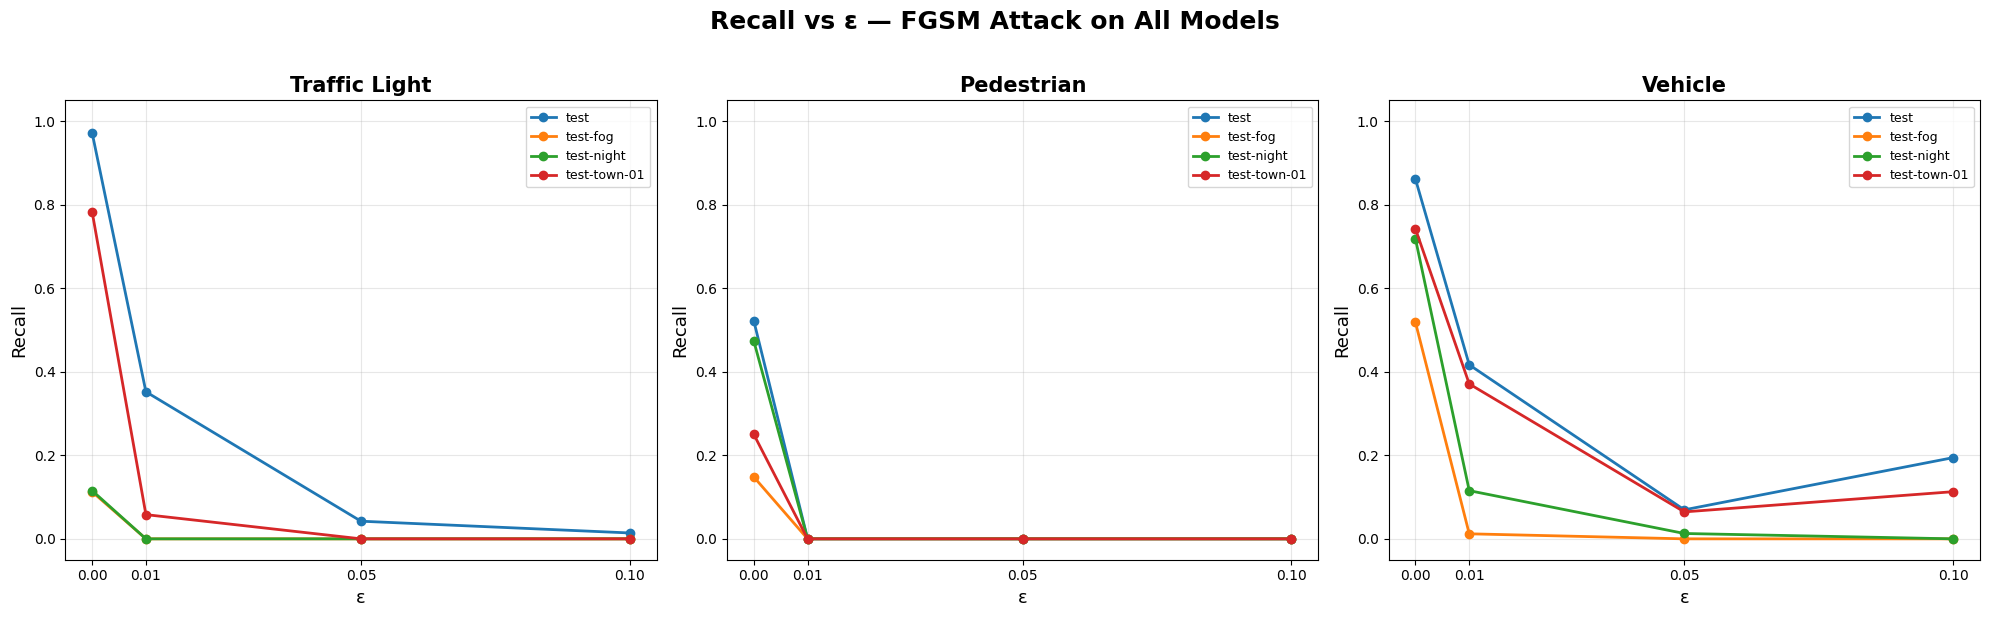

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, label_col in enumerate(LABELS):
    ax = axes[idx]
    tag = label_col.replace('has_','').replace('_',' ').title()

    for split_name in TEST_SPLITS:
        key = (split_name, label_col)
        if key not in recall_drops:
            continue
        rd = recall_drops[key]
        eps_vals = [0.0, 0.01, 0.05, 0.1]
        rec_vals = [rd.get('clean', 0)] + [rd.get(e, 0) for e in [0.01, 0.05, 0.1]]
        ax.plot(eps_vals, rec_vals, 'o-', linewidth=2, markersize=6, label=split_name)

    ax.set_xlabel('ε', fontsize=13)
    ax.set_ylabel('Recall', fontsize=13)
    ax.set_title(f'{tag}', fontsize=15, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xticks([0.0, 0.01, 0.05, 0.1])
    ax.grid(True, alpha=0.3)

plt.suptitle('Recall vs ε — FGSM Attack on All Models',
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/recall_drop_fgsm.png", dpi=150, bbox_inches='tight')
plt.show()



Heatmap — Recall Drop (Split × Model × ε)

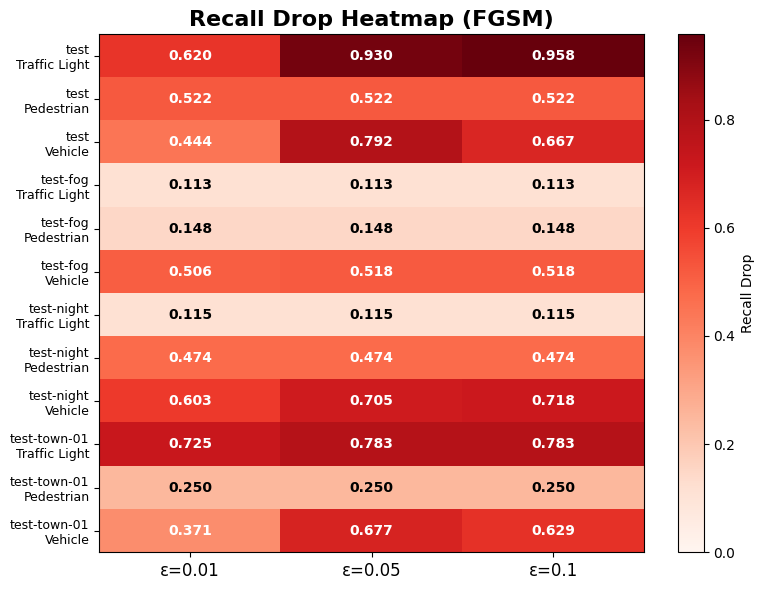

In [ ]:

# Build recall drop matrix for heatmap
split_names = [s for s in TEST_SPLITS if any(r['split']==s for r in results)]
eps_attack = [0.01, 0.05, 0.1]
rows = []
row_labels = []

for split_name in split_names:
    for label_col in LABELS:
        tag = label_col.replace('has_','').replace('_',' ').title()
        row_labels.append(f"{split_name}\n{tag}")

        clean = next((r for r in results
                      if r['split']==split_name and r['model']==label_col and r['epsilon']==0.0), None)
        row = []
        for eps in eps_attack:
            adv = next((r for r in results
                        if r['split']==split_name and r['model']==label_col and r['epsilon']==eps), None)
            if clean and adv:
                row.append(clean['recall'] - adv['recall'])
            else:
                row.append(0)
        rows.append(row)

matrix = np.array(rows)

fig, ax = plt.subplots(figsize=(8, max(6, len(row_labels) * 0.5)))
import matplotlib.colors as mcolors
cmap = plt.cm.Reds
im = ax.imshow(matrix, cmap=cmap, aspect='auto', vmin=0, vmax=max(0.5, matrix.max()))

ax.set_xticks(range(len(eps_attack)))
ax.set_xticklabels([f'ε={e}' for e in eps_attack], fontsize=12)
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=9)

# Annotate cells
for i in range(len(row_labels)):
    for j in range(len(eps_attack)):
        val = matrix[i, j]
        color = 'white' if val > 0.3 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=10, fontweight='bold', color=color)

plt.colorbar(im, ax=ax, label='Recall Drop')
ax.set_title('Recall Drop Heatmap (FGSM)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/recall_drop_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

